In [1]:
# !pip install -r requirements.txt

# Smart Machine Monitoring Accelerator (SMMA)
## End-to-End TinyML Datapath & Bit-True Fixed-Point Golden Model

### 1. Executive Summary & Hardware Datapath
The **Smart Machine Monitoring Accelerator (SMMA)** is a high-performance TinyML/Edge AI solution designed for real-time industrial electric motor condition monitoring deployed on Field-Programmable Gate Array (FPGA) fabric. The system captures 1D high-frequency vibration signals and classifies motor operation into four mechanical fault states:
1. **Normal**: Baseline healthy motor operation.
2. **Unbalance**: Shaft mass eccentricity generating fundamental frequency harmonics.
3. **Misalignment**: Parallel or angular shaft misalignment producing high axial and radial vibrations.
4. **Bearing Wear**: Rolling element micro-defects characterized by high-frequency impact signatures (BPFI/BPFO).

#### Datapath Architecture Pipeline:
```
[ 1D Raw Vibration Signal ]
           │
           ▼
[ 8-Tap Adaptive LMS Filter ]  --> Attenuates broadband acoustic & background noise
           │
           ▼
[ 64-Point FFT Engine ]        --> Extracts 32 magnitude frequency bins per time frame
           │
           ▼
[ Spectrogram Generator ]      --> Accumulates 32 frames to construct a 32x32x1 matrix
           │
           ▼
[ Q8.16 Fixed-Point Quantizer ]--> Converts float magnitude data into 24-bit signed integers
           │
           ▼
[ FPGA Micro-CNN Accelerator ] --> Conv2D (8x 3x3) -> ReLU -> MaxPool (2x2) -> Flatten -> Dense (4 Logits)
```

---

### 2. Hardware Arithmetic Constraints (Q8.16 Fixed-Point Format)
To achieve ultra-low power consumption and minimal LUT/DSP resource utilization on FPGA, the entire inference datapath operates using **24-bit signed fixed-point arithmetic** in **Q8.16 format**:
* **Total Word Length ($N$):** 24 bits
* **Integer Bits ($I$):** 7 bits
* **Fractional Bits ($F$):** 16 bits
* **Sign Bit ($S$):** 1 bit (Two's Complement)
* **Scale Factor ($S_{scale}$):** $2^{16} = 65536$
* **Representable Integer Range:** $[-2^{23}, 2^{23} - 1] = [-8,388,608, +8,388,607]$
* **Representable Real Range:** $[-128.0, +127.99998474121094]$

#### Quantization Math:
Float32 parameters $x_{float}$ are converted to Q8.16 integers $x_{int24}$ via Post-Training Quantization (PTQ):
$$x_{int24} = \text{clip}\left(\text{round}\left(x_{float} \cdot 2^{16}\right), -8388608, 8388607\right)$$

During hardware multiplication, two 24-bit numbers yield a 48-bit product ($Q16.32$). Hardware arithmetic truncation is simulated via arithmetic right shift by 16 bits (`>> 16`), followed by 24-bit saturation logic to prevent overflow wrapping.


In [2]:
# ============================================================================
# Cell 2: Library Imports, Global Seed Initialization, and Hardware Constants
# ============================================================================
import os
import sys
import random
import math
import glob
import copy
from pathlib import Path

import numpy as np
import h5py
import scipy.io as sio

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import Dataset, DataLoader, random_split

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Set deterministic random seeds for reproducible experiments
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Global Directory Settings
BASE_DIR = Path.cwd()
FIGURES_DIR = BASE_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Q8.16 Hardware Fixed-Point Specifications
FRACTIONAL_BITS = 16
TOTAL_BITS = 24
SCALE_FACTOR = 1 << FRACTIONAL_BITS  # 65536
MIN_VAL_Q8_16 = -(1 << (TOTAL_BITS - 1))     # -8388608
MAX_VAL_Q8_16 = (1 << (TOTAL_BITS - 1)) - 1  #  8388607

# Machine State Class Definitions
CLASS_NAMES = ["Normal", "Unbalance", "Misalignment", "Bearing Wear"]
NUM_CLASSES = len(CLASS_NAMES)

print(f"[CONFIG] Hardware Precision : Q8.16 ({TOTAL_BITS}-bit signed, {FRACTIONAL_BITS} fractional bits)")
print(f"[CONFIG] Integer Quant Bounds: [{MIN_VAL_Q8_16}, {MAX_VAL_Q8_16}]")
print(f"[CONFIG] Target Classes     : {CLASS_NAMES}")
print(f"[CONFIG] PyTorch Device     : {'cuda' if torch.cuda.is_available() else 'cpu'}")


[CONFIG] Hardware Precision : Q8.16 (24-bit signed, 16 fractional bits)
[CONFIG] Integer Quant Bounds: [-8388608, 8388607]
[CONFIG] Target Classes     : ['Normal', 'Unbalance', 'Misalignment', 'Bearing Wear']
[CONFIG] PyTorch Device     : cuda


### 3. Front-End DSP Pipeline Simulation
The front-end processing unit cleans raw 1D sensor telemetry and constructs time-frequency feature maps:
1. **8-Tap Adaptive LMS Filter**: Cancels broadband background noise using an adaptive FIR structure.
2. **64-Point FFT Engine & Spectrogram Generator**: Slices 2048 time samples into 32 windows of 64 samples, calculates real FFT magnitude across 32 frequency channels, and quantizes the resulting $32 \times 32$ matrix to Q8.16 fixed-point format.


In [3]:
# ============================================================================
# Adaptive LMS Filter
# ============================================================================

class LMS_Filter_Simulator:
    """
    Simulates an 8-Tap Adaptive Least Mean Squares (LMS) FIR Filter for 1D raw vibration signals.
    Attenuates broadband noise prior to spectral feature extraction.
    """
    def __init__(self, num_taps=8, mu=0.01):
        self.num_taps = num_taps
        self.mu = mu
        self.weights = np.zeros(num_taps, dtype=np.float32)

    def filter_signal(self, input_signal, reference_noise=None):
        """
        Applies adaptive LMS filtering over a 1D input array.
        """
        n_samples = len(input_signal)
        output_signal = np.zeros(n_samples, dtype=np.float32)
        
        if reference_noise is None:
            # Generate synthesized correlated reference noise if external reference unavailable
            reference_noise = np.roll(input_signal, 1) * 0.1
            
        buffer = np.zeros(self.num_taps, dtype=np.float32)
        
        for i in range(n_samples):
            # Shift buffer right and insert new sample at index 0
            buffer[1:] = buffer[:-1]
            buffer[0] = reference_noise[i]
            
            # Compute filter output: y = w^T * x
            y = np.dot(self.weights, buffer)
            
            # Compute error: e = d - y
            e = input_signal[i] - y
            output_signal[i] = e
            
            buffer_power = np.dot(buffer, buffer) + 1e-6
            
            # 3. Scale down the step size by the signal power
            normalized_mu = self.mu / buffer_power
            
            # 4. Update weights safely
            self.weights += 2.0 * normalized_mu * e * buffer
            
        return output_signal


In [4]:
# ------------------------------------------------------------------------------
# Frequency-Domain LMS (FDLMS)
# ------------------------------------------------------------------------------
class FDLMS_Filter_Simulator:
    def __init__(self, num_bins, mu=0.005):
        self.mu = mu
        self.weights = np.zeros(num_bins, dtype=np.complex64)

    def filter_spectrogram(self, stft_matrix):
        """ Applies Frequency-Domain Adaptive Line Enhancement (ALE) """
        num_frames, num_bins = stft_matrix.shape
        output_stft = np.zeros_like(stft_matrix, dtype=np.complex64)
        
        # Reference is the delayed spectrum
        reference_noise = np.roll(stft_matrix, 1, axis=0) * 0.1
        
        for t in range(num_frames):
            x = reference_noise[t] 
            d = stft_matrix[t]
            
            y = self.weights * x
            e = d - y
            output_stft[t] = e
            
            signal_power = np.abs(x)**2 + 1e-6
            
            # 2. Scale down the step size
            normalized_mu = self.mu / signal_power
            
            # 3. Update complex weights safely
            self.weights += 2.0 * normalized_mu * e * np.conj(x)
            
        return output_stft

In [5]:
# ------------------------------------------------------------------------------
# PIPELINE A: Time-Domain LMS -> FFT -> Spectrogram
# ------------------------------------------------------------------------------
class PipelineA_Preprocessor:
    """
    Front-end Spectrogram Preprocessor:
    1. Optionally applies Adaptive LMS noise cancellation.
    2. Reshapes 2048 raw samples into 32 time frames of 64 samples each.
    3. Computes 64-point FFT and extracts 32 magnitude bins per frame.
    4. Quantizes the final 32x32x1 spectrogram into Q8.16 fixed-point format.
    """
    def __init__(self, frame_size=64, num_frames=32, use_lms=True):
        self.frame_size = frame_size
        self.num_frames = num_frames
        self.expected_samples = frame_size * num_frames # 2048 samples
        self.use_lms = use_lms
        if self.use_lms:
            self.lms_filter = LMS_Filter_Simulator(num_taps=8, mu=0.005)

    def process(self, raw_signal):
        """
        Processes 1D float array -> returns (32, 32, 1) Q8.16 numpy array (int64/int32).
        """
        raw_signal = np.asarray(raw_signal, dtype=np.float32)
        
        # Ensure input length matches expected window (2048 samples)
        if len(raw_signal) < self.expected_samples:
            raw_signal = np.pad(raw_signal, (0, self.expected_samples - len(raw_signal)))
        else:
            raw_signal = raw_signal[:self.expected_samples]
            
        # Apply Adaptive LMS Filter
        if self.use_lms:
            filtered_signal = self.lms_filter.filter_signal(raw_signal)
        else:
            filtered_signal = raw_signal

        # Reshape into 32 frames of 64 samples
        frames = filtered_signal.reshape((self.num_frames, self.frame_size))
        
        # Pre-allocate spectrogram matrix (32 frames, 32 magnitude bins)
        spectrogram = np.zeros((self.num_frames, self.frame_size // 2), dtype=np.float32)
        
        for i in range(self.num_frames):
            fft_complex = np.fft.rfft(frames[i])
            # Select first 32 magnitude bins
            spectrogram[i, :] = np.abs(fft_complex[:32])
            
        # Expand channel dimension -> (32, 32, 1)
        spectrogram_3d = spectrogram[:, :, np.newaxis]
        
        # Quantize to Q8.16 Integer Representation
        scaled = np.round(spectrogram_3d * SCALE_FACTOR)
        spectrogram_q8_16 = np.clip(scaled, MIN_VAL_Q8_16, MAX_VAL_Q8_16).astype(np.int32)
        
        return spectrogram_q8_16

In [6]:
# ------------------------------------------------------------------------------
# PIPELINE B: FFT -> FDLMS -> Spectrogram
# ------------------------------------------------------------------------------

class PipelineB_Preprocessor:
    def __init__(self, frame_size=64, num_frames=32, use_lms=True):
        self.frame_size = frame_size
        self.num_frames = num_frames
        self.expected_samples = frame_size * num_frames
        self.use_lms = use_lms
        if self.use_lms:
            self.fdlms_filter = FDLMS_Filter_Simulator(num_bins=self.frame_size // 2, mu=0.005)

    def process(self, raw_signal):
        raw_signal = np.asarray(raw_signal, dtype=np.float32)
        if len(raw_signal) < self.expected_samples:
            raw_signal = np.pad(raw_signal, (0, self.expected_samples - len(raw_signal)))
        else:
            raw_signal = raw_signal[:self.expected_samples]
            
        frames = raw_signal.reshape((self.num_frames, self.frame_size))
        stft_matrix = np.zeros((self.num_frames, self.frame_size // 2), dtype=np.complex64)
        
        # 1. FFT first
        for i in range(self.num_frames):
            stft_matrix[i, :] = np.fft.rfft(frames[i])[:32]
            
        # 2. Apply FDLMS on the frequency domain
        if self.use_lms:
            filtered_stft = self.fdlms_filter.filter_spectrogram(stft_matrix)
        else:
            filtered_stft = stft_matrix
            
        # 3. Magnitude and Quantize to Q8.16
        spectrogram = np.abs(filtered_stft)
        spectrogram_3d = spectrogram[:, :, np.newaxis]
        scaled = np.round(spectrogram_3d * SCALE_FACTOR)
        return np.clip(scaled, MIN_VAL_Q8_16, MAX_VAL_Q8_16).astype(np.int32)

In [7]:
# ------------------------------------------------------------------------------
# VISUALIZATION
# ------------------------------------------------------------------------------
def compare_pipelines(raw_signal):
    """
    3. DSP Visualization: Shows side-by-side comparison of Pipeline A vs B.
    """
    pre_A = PipelineA_Preprocessor()
    pre_B = PipelineB_Preprocessor()
    
    spec_A = pre_A.process(raw_signal)
    spec_B = pre_B.process(raw_signal)
    
    # Convert back to float for Matplotlib
    spec_A_vis = spec_A[:, :, 0].astype(np.float32) / SCALE_FACTOR
    spec_B_vis = spec_B[:, :, 0].astype(np.float32) / SCALE_FACTOR
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    im1 = axes[0].imshow(spec_A_vis.T, aspect='auto', origin='lower', cmap='magma')
    axes[0].set_title('Pipeline A: Time-LMS -> FFT')
    axes[0].set_xlabel('Time Frame')
    axes[0].set_ylabel('Frequency Bin')
    fig.colorbar(im1, ax=axes[0])
    
    im2 = axes[1].imshow(spec_B_vis.T, aspect='auto', origin='lower', cmap='magma')
    axes[1].set_title('Pipeline B: FFT -> FDLMS')
    axes[1].set_xlabel('Time Frame')
    axes[1].set_ylabel('Frequency Bin')
    fig.colorbar(im2, ax=axes[1])
    
    plt.tight_layout()
    plt.show()

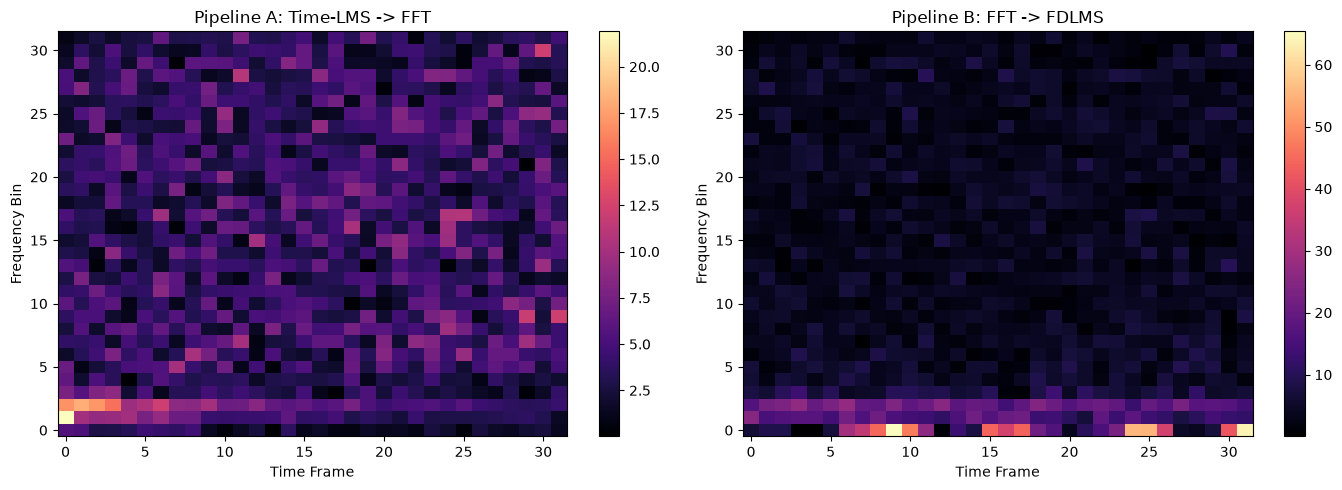

In [8]:
# Verify Preprocessor execution
dummy_1d_signal = np.sin(2 * np.pi * 50 * np.linspace(0, 1, 2048)) + 0.5 * np.random.randn(2048)
compare_pipelines(dummy_1d_signal)

### 4. Dataset Processing & PyTorch HDF5 Loader
Vibration telemetry is segmented into 2048-sample chunks to construct 32x32 Q8.16 matrices. The processed feature maps are stored in a structured HDF5 file (`smma_dataset.h5`) to optimize disk throughput and memory footprint.


In [9]:
# ==============================================================================
# DUAL DATASET GENERATION
# ==============================================================================

def build_h5_datasets(data_dir, output_a="dataset_pipeline_A.h5", output_b="dataset_pipeline_B.h5", chunk_size=2048, overlap=1024):
    """
    Iterates through .mat files, extracts 4 vibration channels, chunks them,
    and runs them through Pipeline A and Pipeline B.
    Outputs two Early Fusion datasets of shape (Batch, 32, 32, 4).
    """
    pre_A = PipelineA_Preprocessor()
    pre_B = PipelineB_Preprocessor()
    
    label_map = {
        'normal': 0,
        'unbalance': 1,
        'misalign': 2,
        'bearing': 3,
        'bpfi': 3,
        'bpfo': 3
    }
    
    mat_files = glob.glob(os.path.join(data_dir, '**', '*.mat'), recursive=True)
    if not mat_files:
        print(f"[ERROR] No .mat files found in {data_dir}")
        return
        
    print(f"[DATASET] Found {len(mat_files)} .mat files. Beginning Dual-Pipeline generation...")

    with h5py.File(output_a, 'w') as h5_a, h5py.File(output_b, 'w') as h5_b:
        
        # Consistent key naming: 'features' and 'labels'
        ds_a_x = h5_a.create_dataset('features', shape=(0, 32, 32, 4), maxshape=(None, 32, 32, 4), dtype='i4', compression='gzip')
        ds_a_y = h5_a.create_dataset('labels', shape=(0,), maxshape=(None,), dtype='i8')
        
        ds_b_x = h5_b.create_dataset('features', shape=(0, 32, 32, 4), maxshape=(None, 32, 32, 4), dtype='i4', compression='gzip')
        ds_b_y = h5_b.create_dataset('labels', shape=(0,), maxshape=(None,), dtype='i8')
        
        buffer_a_x, buffer_a_y = [], []
        buffer_b_x, buffer_b_y = [], []
        
        total_samples = 0
        batch_write_size = 500  # Buffer samples in memory before flushing to HDF5
        
        for file_path in mat_files:
            filename_lower = os.path.basename(file_path).lower()
            label = -1
            
            for key, val in label_map.items():
                if key in filename_lower:
                    label = val
                    break
            
            if label == -1:
                continue
                
            try:
                data = sio.loadmat(file_path)
                raw_matrix = data['Signal']['y_values'][0, 0]['values'][0, 0]
                
                ch0 = raw_matrix[:, 0]
                ch1 = raw_matrix[:, 1]
                ch2 = raw_matrix[:, 2]
                ch3 = raw_matrix[:, 3]
                channels = [ch0, ch1, ch2, ch3]
                
            except Exception as e:
                print(f"[WARNING] Skipping {filename_lower}: Unrecognized MAT structure. {e}")
                continue

            signal_length = len(channels[0])
            for start_idx in range(0, signal_length - chunk_size + 1, chunk_size - overlap):
                end_idx = start_idx + chunk_size

                spec_A_list = []
                spec_B_list = []

                for ch_data in channels:
                    chunk = ch_data[start_idx:end_idx]
                    spec_A_list.append(pre_A.process(chunk))
                    spec_B_list.append(pre_B.process(chunk))

                early_fusion_A = np.concatenate(spec_A_list, axis=2)
                early_fusion_B = np.concatenate(spec_B_list, axis=2)

                buffer_a_x.append(early_fusion_A)
                buffer_a_y.append(label)
                buffer_b_x.append(early_fusion_B)
                buffer_b_y.append(label)

                # Flush buffers to HDF5 in batches for optimal disk write speed
                if len(buffer_a_x) >= batch_write_size:
                    _append_to_h5(ds_a_x, ds_a_y, buffer_a_x, buffer_a_y)
                    _append_to_h5(ds_b_x, ds_b_y, buffer_b_x, buffer_b_y)
                    total_samples += len(buffer_a_x)
                    buffer_a_x.clear()
                    buffer_a_y.clear()
                    buffer_b_x.clear()
                    buffer_b_y.clear()
                    print(f"[DATASET] Processed {total_samples} 4-channel tensor samples...")

        # Flush any remaining samples
        if buffer_a_x:
            _append_to_h5(ds_a_x, ds_a_y, buffer_a_x, buffer_a_y)
            _append_to_h5(ds_b_x, ds_b_y, buffer_b_x, buffer_b_y)
            total_samples += len(buffer_a_x)

    print(f"\n[SUCCESS] Datasets generated! Total 4-channel samples: {total_samples}")
    print(f" -> {output_a}")
    print(f" -> {output_b}")


def _append_to_h5(ds_x, ds_y, buffer_x, buffer_y):
    """Helper function to resize and append batch arrays to HDF5 datasets."""
    current_len = ds_x.shape[0]
    new_len = current_len + len(buffer_x)
    
    ds_x.resize(new_len, axis=0)
    ds_y.resize(new_len, axis=0)
    
    ds_x[current_len:new_len] = np.array(buffer_x, dtype='i4')
    ds_y[current_len:new_len] = np.array(buffer_y, dtype='i8')

In [10]:
build_h5_datasets(data_dir='../dataset/vibration',
                  output_a="dataset_pipeline_A.h5",
                  output_b="dataset_pipeline_B.h5")

[DATASET] Found 45 .mat files. Beginning Dual-Pipeline generation...
[DATASET] Processed 500 4-channel tensor samples...
[DATASET] Processed 1000 4-channel tensor samples...
[DATASET] Processed 1500 4-channel tensor samples...
[DATASET] Processed 2000 4-channel tensor samples...
[DATASET] Processed 2500 4-channel tensor samples...
[DATASET] Processed 3000 4-channel tensor samples...
[DATASET] Processed 3500 4-channel tensor samples...
[DATASET] Processed 4000 4-channel tensor samples...
[DATASET] Processed 4500 4-channel tensor samples...
[DATASET] Processed 5000 4-channel tensor samples...
[DATASET] Processed 5500 4-channel tensor samples...
[DATASET] Processed 6000 4-channel tensor samples...
[DATASET] Processed 6500 4-channel tensor samples...
[DATASET] Processed 7000 4-channel tensor samples...
[DATASET] Processed 7500 4-channel tensor samples...
[DATASET] Processed 8000 4-channel tensor samples...
[DATASET] Processed 8500 4-channel tensor samples...
[DATASET] Processed 9000 4-chan

In [11]:
def visualize_spectrogram_samples(h5_path, num_samples=4):
    """Plots sample spectrograms for each mechanical state."""
    with h5py.File(h5_path, 'r') as h5f:
        X = h5f['X']
        Y = h5f['Y']
        total = X.shape[0]

        # Guard clause to prevent ValueError if dataset is empty
        if total == 0:
            print("[EVAL] Error: HDF5 dataset is empty. Cannot visualize samples.")
            return
        
        indices = random.sample(range(total), num_samples)
        plt.figure(figsize=(14, 3.5))
        
        for i, idx in enumerate(indices):
            spec_float = X[idx, :, :, 0].astype(np.float32) / SCALE_FACTOR
            label_idx = Y[idx]
            
            plt.subplot(1, num_samples, i + 1)
            plt.imshow(spec_float, cmap='viridis', aspect='auto', origin='lower')
            plt.colorbar(label='Magnitude')
            plt.title(f"State: {CLASS_NAMES[label_idx]} | Sample #{idx}")
            plt.xlabel("Time Frame")
            plt.ylabel("Frequency Bin")
            
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "sample_spectrograms.png", dpi=150)
        plt.show()

In [12]:
# ============================================================================
# PyTorch HDF5 Data Pipeline
# ============================================================================

class SMMADataset(Dataset):
    """
    Optimized PyTorch Dataset. Pre-loads and converts the HDF5 dataset in RAM
    to achieve maximum throughput during training.
    """
    def __init__(self, h5_path):
        self.h5_path = h5_path
        print(f"[DATASET] Pre-loading entire HDF5 dataset into RAM from: {self.h5_path}")
        
        with h5py.File(self.h5_path, 'r') as h5f:
            # Read from unified keys: 'features' and 'labels'
            x_raw = h5f['features'][:]  # Shape: (N, 32, 32, 4)
            y_raw = h5f['labels'][:]    # Shape: (N,)
            
        # Convert Q8.16 integer back to float32 once for the whole dataset in RAM
        x_float = x_raw.astype(np.float32) / SCALE_FACTOR
        
        # Convert to PyTorch Tensors and transpose from (N, H, W, C) -> (N, C, H, W)
        self.X_tensor = torch.from_numpy(x_float).permute(0, 3, 1, 2).contiguous()
        self.Y_tensor = torch.from_numpy(y_raw).long()
        self.length = self.X_tensor.shape[0]
        
        print(f"[DATASET] Loaded {self.length} samples into RAM with shape {tuple(self.X_tensor.shape)}.")

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # Direct zero-copy memory
        return self.X_tensor[idx], self.Y_tensor[idx]

### 5. PyTorch Micro-CNN Architecture
The floating-point Micro-CNN network mirrors the exact topology implemented in the FPGA hardware fabric.

#### Layer Dimension Tracking:
* **Input Tensor:** $(B, 1, 32, 32)$
* **Conv2D Layer:** $8 \text{ filters of } 3 \times 3, \text{ stride}=1, \text{ padding}=1 \longrightarrow (B, 8, 32, 32)$
* **ReLU Activation:** Element-wise $\max(0, x) \longrightarrow (B, 8, 32, 32)$
* **MaxPool2D Layer:** $2 \times 2 \text{ window}, \text{ stride}=2 \longrightarrow (B, 8, 16, 16)$
* **Flatten Layer:** Reshape to 1D vector $\longrightarrow (B, 2048)$
* **Dense Layer:** Fully connected linear map $(2048 \rightarrow 4) \longrightarrow (B, 4 \text{ Logits})$


In [13]:
# ============================================================================
# Cell 5: PyTorch SMMA Micro-CNN Architecture
# ============================================================================

class PyTorch_SMMA_CNN(nn.Module):
    """
    Hardware-equivalent PyTorch Micro-CNN for motor fault classification.
    """
    def __init__(self):
        super(PyTorch_SMMA_CNN, self).__init__()
        # Conv2D: 4 Input Channel, 8 Filters, 3x3 Kernel, Stride 1, Padding 1
        self.conv1 = nn.Conv2d(in_channels=4, out_channels=8, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        # MaxPool2D: 2x2 Window, Stride 2
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.flatten = nn.Flatten()
        # Dense Layer: 8 channels * 16 height * 16 width = 2048 inputs -> 4 outputs
        self.dense1 = nn.Linear(in_features=2048, out_features=NUM_CLASSES)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.flatten(x)
        x = self.dense1(x)
        return x

# Instantiate model and output summary
model_preview = PyTorch_SMMA_CNN()
print(model_preview)
dummy_tensor = torch.randn(1, 4, 32, 32)
out_logits = model_preview(dummy_tensor)
print(f"[MODEL] Output Logits Shape: {out_logits.shape} (Expected: [1, 4])")


PyTorch_SMMA_CNN(
  (conv1): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dense1): Linear(in_features=2048, out_features=4, bias=True)
)
[MODEL] Output Logits Shape: torch.Size([1, 4]) (Expected: [1, 4])


### 6. Training Pipeline & Regularization Strategies
To ensure robust generalization and prevent overfitting on edge devices, the training procedure incorporates:
1. **Weighted Cross-Entropy Loss**: Class weights computed from inverse class frequencies address dataset imbalance.
2. **Gaussian Noise Injection**: Zero-mean noise ($\sigma=0.05$) is injected into input feature maps during training for data augmentation.
3. **StepLR Scheduler**: Reduces learning rate by $50\%$ every 15 epochs to refine weight convergence.
4. **Early Stopping**: Prevents over-fitting by tracking validation loss with a patience threshold.


In [17]:
class EarlyStopping:
    """
    Early stopping monitor. Saves the best model weights in self.best_state
    when validation loss improves.
    """
    def __init__(self, patience=7, delta=0.0):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False
        self.best_state = None

    def __call__(self, val_loss, model):
        if val_loss < (self.best_loss - self.delta):
            self.best_loss = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

In [18]:
# ==============================================================================
# DUAL MODEL TRAINING & EVALUATION
# ==============================================================================

def train_and_evaluate(h5_path, model_class, batch_size=32, epochs=20, lr=1e-3, seed=42):
    """
    Executes a complete training and validation cycle with reproducible dataset splits.
    """
    dataset = HDF5Dataset(h5_path)
    
    # 80/20 Train/Validation Split with deterministic seed generator
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    generator = torch.Generator().manual_seed(seed)
    
    train_dataset, val_dataset = random_split(
        dataset, 
        [train_size, val_size], 
        generator=generator
    )
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"[{h5_path}] Training on {device}...")
    
    model = model_class().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    early_stopper = EarlyStopping(patience=7)
    
    for epoch in range(epochs):
        # --- TRAINING ---
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data).item()
            total += inputs.size(0)
            
        epoch_train_loss = running_loss / total
        epoch_train_acc = correct / total
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        
        # --- VALIDATION ---
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += torch.sum(preds == labels.data).item()
                val_total += inputs.size(0)
                
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        
        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            
        # Logging
        print(f"Epoch [{epoch+1:02d}/{epochs:02d}] | "
              f"Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc * 100.0:.2f}% | "
              f"Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc * 100.0:.2f}%")
        
        early_stopper(epoch_val_loss, model)
        if early_stopper.early_stop:
            print(f"[{h5_path}] Early stopping triggered at epoch {epoch+1}. Restoring best model state.")
            if early_stopper.best_state is not None:
                best_model_wts = early_stopper.best_state
            break

    print(f"[{h5_path}] Training Complete. Best Val Acc: {best_acc:.4f}\n")
    
    # Load best weights to compute final metrics
    model.load_state_dict(best_model_wts)
    
    all_preds = []
    all_labels = []
    model.eval()
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    cm = confusion_matrix(all_labels, all_preds)
    
    return history, cm, model

In [19]:
# --- EXECUTION AND COMPARATIVE ANALYSIS ---
def run_phase3_evaluation(epochs=20):
    # Pass the class reference of your existing model
    history_A, cm_A, model_A = train_and_evaluate("dataset_pipeline_A.h5", PyTorch_SMMA_CNN,
epochs=epochs)
    history_B, cm_B, model_B = train_and_evaluate("dataset_pipeline_B.h5", PyTorch_SMMA_CNN,
epochs=epochs)
    
    # 1. Plotting Learning Curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(history_A['val_acc'], label='Pipeline A (Time LMS) Val Acc', color='tab:blue',
marker='o')
    axes[0].plot(history_B['val_acc'], label='Pipeline B (FDLMS) Val Acc', color='tab:orange',
marker='s')
    axes[0].set_title('Validation Accuracy Comparison')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)
    
    axes[1].plot(history_A['val_loss'], label='Pipeline A (Time LMS) Val Loss', color='tab:blue',
marker='o')
    axes[1].plot(history_B['val_loss'], label='Pipeline B (FDLMS) Val Loss', color='tab:orange',
marker='s')
    axes[1].set_title('Validation Loss Comparison')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    # 2. Plotting Confusion Matrices
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    class_names = ['Normal', 'Unbalance', 'Misalign', 'Bearing']
    
    sns.heatmap(cm_A, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names,
ax=axes[0])
    axes[0].set_title('Confusion Matrix: Pipeline A (Time LMS)')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')
    
    sns.heatmap(cm_B, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names,
yticklabels=class_names, ax=axes[1])
    axes[1].set_title('Confusion Matrix: Pipeline B (FDLMS)')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')
    
    plt.tight_layout()
    plt.show()

    return model_A, model_B

[dataset_pipeline_A.h5] Training on cuda...
Epoch [01/70] | Train Loss: 0.1372, Acc: 94.70% | Val Loss: 0.0713, Acc: 97.38%
Epoch [02/70] | Train Loss: 0.0646, Acc: 97.62% | Val Loss: 0.0562, Acc: 97.87%
Epoch [03/70] | Train Loss: 0.0478, Acc: 98.31% | Val Loss: 0.0694, Acc: 97.83%
Epoch [04/70] | Train Loss: 0.0433, Acc: 98.57% | Val Loss: 0.0498, Acc: 98.47%
Epoch [05/70] | Train Loss: 0.0382, Acc: 98.74% | Val Loss: 0.0374, Acc: 98.79%
Epoch [06/70] | Train Loss: 0.0333, Acc: 98.92% | Val Loss: 0.0375, Acc: 98.73%
Epoch [07/70] | Train Loss: 0.0370, Acc: 98.84% | Val Loss: 0.0627, Acc: 97.99%
Epoch [08/70] | Train Loss: 0.0323, Acc: 98.98% | Val Loss: 0.0439, Acc: 98.89%
Epoch [09/70] | Train Loss: 0.0332, Acc: 99.01% | Val Loss: 0.0739, Acc: 98.19%
Epoch [10/70] | Train Loss: 0.0291, Acc: 99.09% | Val Loss: 0.0567, Acc: 98.52%
Epoch [11/70] | Train Loss: 0.0274, Acc: 99.16% | Val Loss: 0.0489, Acc: 98.68%
Epoch [12/70] | Train Loss: 0.0294, Acc: 99.11% | Val Loss: 0.0697, Acc: 98.

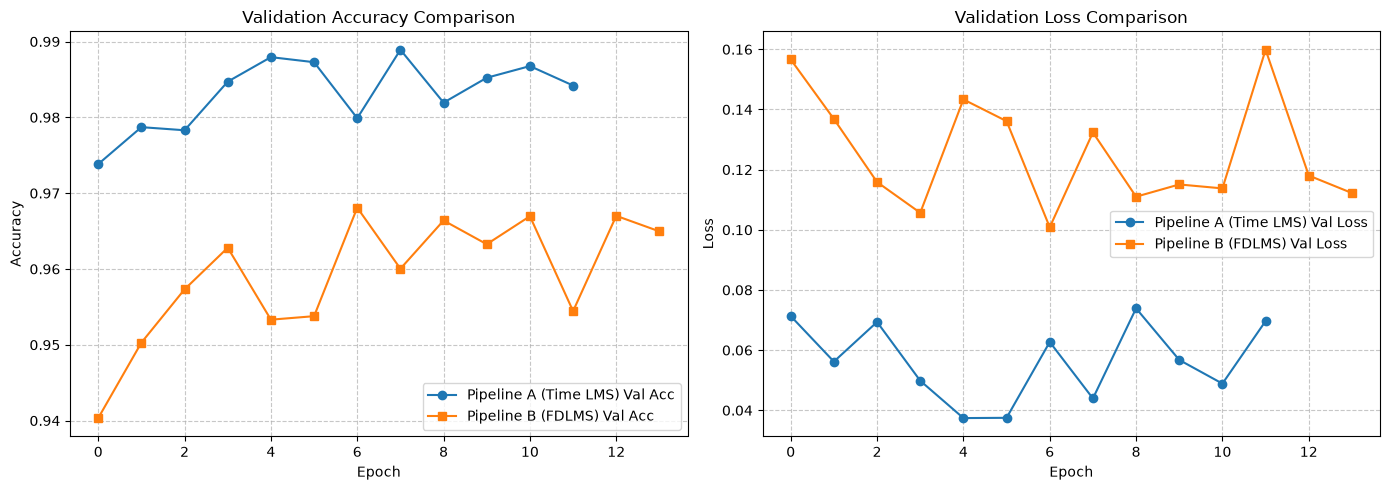

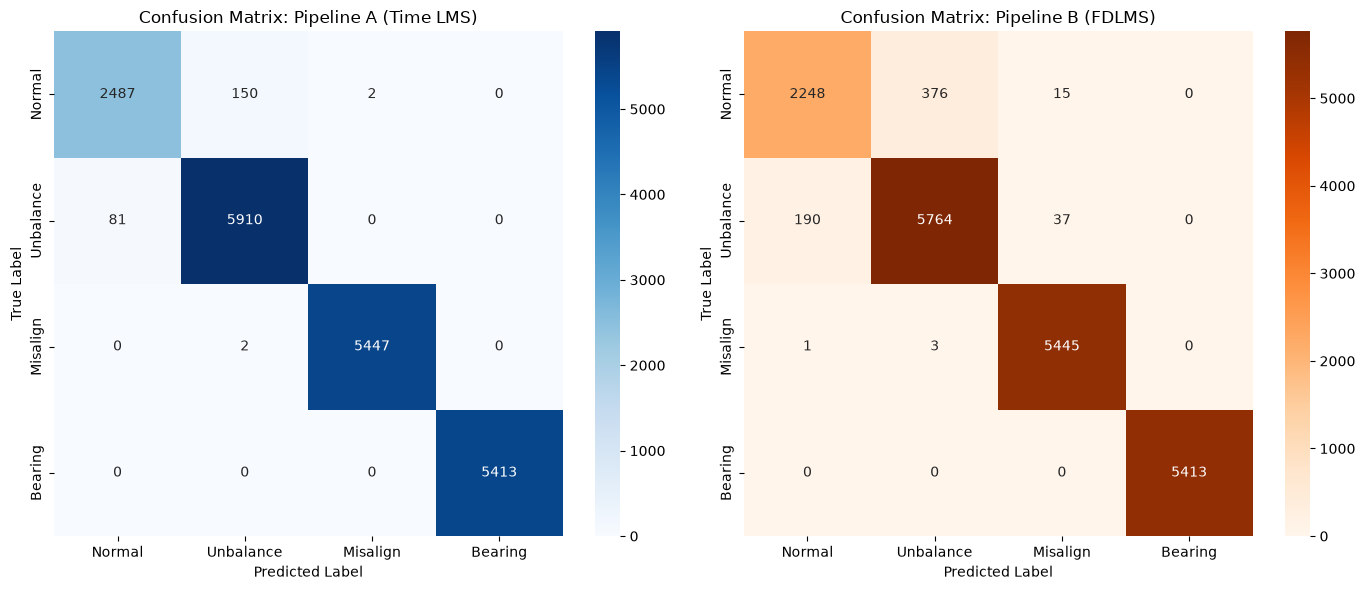

In [20]:
trained_model_A, trained_model_B = run_phase3_evaluation(epochs=70)

In [21]:
# ============================================================================
# Cell 8: Q8.16 Post-Training Weight Quantization Exporter
# ============================================================================

def export_q8_16_weights(model, model_name, base_dir):
    """
    Converts Float32 PyTorch weights into 24-bit Q8.16 signed integer representations.
    Exports both the native PyTorch state (.pth) and the quantized archive (.npz).
    """
    print("-" * 70)
    print(f"[EXPORT] Processing architecture: {model_name}")
    
    # Define distinct output paths to avoid cross-contamination
    pytorch_model_path = base_dir / f"{model_name}.pth"
    q8_16_weights_path = base_dir / f"{model_name}_q8_16.npz"
    
    # 1. Save Float32 model state (Python evaluation backup)
    torch.save(model.state_dict(), pytorch_model_path)
    print(f"[EXPORT] PyTorch Float32 state saved to {pytorch_model_path}")
    
    # 2. Extract Floating-Point Weights
    conv_w = model.conv1.weight.detach().cpu().numpy()
    conv_b = model.conv1.bias.detach().cpu().numpy()
    dense_w = model.dense1.weight.detach().cpu().numpy()
    dense_b = model.dense1.bias.detach().cpu().numpy()
    
    def to_q8_16(val):
        """ Scales and clamps floating values to absolute hardware limits. """
        scaled = np.round(val * SCALE_FACTOR)
        return np.clip(scaled, MIN_VAL_Q8_16, MAX_VAL_Q8_16).astype(np.int64)

    # 3. Apply Q8.16 Hardware Quantization
    q8_conv_w = to_q8_16(conv_w)
    q8_conv_b = to_q8_16(conv_b)
    q8_dense_w = to_q8_16(dense_w)
    q8_dense_b = to_q8_16(dense_b)
    
    # 4. Save Quantized Archive for Hardware Stimulus
    np.savez(q8_16_weights_path, 
             conv1_w=q8_conv_w, conv1_b=q8_conv_b,
             dense1_w=q8_dense_w, dense1_b=q8_dense_b)
             
    print(f"[EXPORT] Successfully saved Q8.16 integer weights to {q8_16_weights_path}")
    print(f"         conv1_w shape: {q8_conv_w.shape}, min/max: [{q8_conv_w.min()}, {q8_conv_w.max()}]")
    print(f"         dense1_w shape: {q8_dense_w.shape}, min/max: [{q8_dense_w.min()}, {q8_dense_w.max()}]")


In [22]:
# Save Float32 model state and export Q8.16 weights archive
export_q8_16_weights(trained_model_A, "smma_model_pipeline_A", BASE_DIR)
export_q8_16_weights(trained_model_B, "smma_model_pipeline_B", BASE_DIR)

----------------------------------------------------------------------
[EXPORT] Processing architecture: smma_model_pipeline_A
[EXPORT] PyTorch Float32 state saved to /home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV/Scripts/cnn/smma_model_pipeline_A.pth
[EXPORT] Successfully saved Q8.16 integer weights to /home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV/Scripts/cnn/smma_model_pipeline_A_q8_16.npz
         conv1_w shape: (8, 4, 3, 3), min/max: [-18857, 21804]
         dense1_w shape: (4, 2048), min/max: [-28654, 25386]
----------------------------------------------------------------------
[EXPORT] Processing architecture: smma_model_pipeline_B
[EXPORT] PyTorch Float32 state saved to /home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV/Scripts/cnn/smma_model_pipeline_B.pth
[EXPORT] Successfully saved Q8.16 integer weights to /home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV/Scripts/cnn/smma_model_pipeline_

### 9. Bit-True Golden Model Hardware Simulation
The **Bit-True Golden Model** is a pure NumPy execution framework designed to simulate exact FPGA hardware behavior down to the bit-level without relying on PyTorch or deep learning frameworks.

#### Hardware Bit-True Arithmetic Features:
1. **24-bit Saturating Addition (`q8_16_add`)**: Adds two Q8.16 integers and clamps results to $[-8388608, 8388607]$.
2. **24x24-bit Multiplication (`q8_16_mul`)**: Multiplies two 24-bit integers yielding a 48-bit intermediate product, arithmetic right-shifts by 16 bits (`>> 16`) to truncate fractional expansion, and saturates to 24 bits.
3. **Hardware Conv2D Layer (`Conv2D_Q8_16`)**: Simulates FPGA line-buffer sliding windows and parallel Multiply-Accumulate (MAC) trees.
4. **Hardware ReLU (`ReLU_Q8_16`)**: Inspects Most Significant Bit (MSB sign bit) to zero out negative values.
5. **Hardware MaxPool2D (`Pooling_Q8_16`)**: Implements $2 \times 2$ comparator trees across feature maps.
6. **Hardware Dense Layer (`Dense_Q8_16`)**: Executes matrix-vector MAC accumulation with Q8.16 truncation.


In [24]:
# ============================================================================
# Bit-True Fixed-Point Golden Model Inference Simulation
# ============================================================================

def float_to_q8_16(val):
    scaled = np.round(val * SCALE_FACTOR)
    return np.clip(scaled, MIN_VAL_Q8_16, MAX_VAL_Q8_16).astype(np.int64)

def q8_16_to_float(val):
    return val / float(SCALE_FACTOR)

def q8_16_add(a, b):
    res = a + b
    return np.clip(res, MIN_VAL_Q8_16, MAX_VAL_Q8_16).astype(np.int64)

def q8_16_mul(a, b):
    # Simulates 24x24 multiplication with 48-bit intermediate product and 16-bit right-shift truncation
    prod = a.astype(np.int64) * b.astype(np.int64)
    truncated = prod >> FRACTIONAL_BITS
    return np.clip(truncated, MIN_VAL_Q8_16, MAX_VAL_Q8_16).astype(np.int64)


class Conv2D_Q8_16:
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.weights = np.zeros((out_channels, in_channels, kernel_size, kernel_size), dtype=np.int64)
        self.biases = np.zeros((out_channels,), dtype=np.int64)
        
    def set_weights(self, w_q8, b_q8):
        self.weights = w_q8
        self.biases = b_q8

    def forward(self, x):
        h_in, w_in, c_in = x.shape
        h_out = (h_in + 2 * self.padding - self.kernel_size) // self.stride + 1
        w_out = (w_in + 2 * self.padding - self.kernel_size) // self.stride + 1
        
        if self.padding > 0:
            x_pad = np.pad(x, ((self.padding, self.padding), (self.padding, self.padding), (0, 0)),
                           mode='constant', constant_values=0)
        else:
            x_pad = x
            
        out = np.zeros((h_out, w_out, self.out_channels), dtype=np.int64)
        
        for i in range(h_out):
            for j in range(w_out):
                y_start, x_start = i * self.stride, j * self.stride
                window = x_pad[y_start:y_start+self.kernel_size, x_start:x_start+self.kernel_size, :]
                
                for oc in range(self.out_channels):
                    acc = self.biases[oc]
                    for ic in range(self.in_channels):
                        for kh in range(self.kernel_size):
                            for kw in range(self.kernel_size):
                                pixel = window[kh, kw, ic]
                                weight = self.weights[oc, ic, kh, kw]
                                prod = q8_16_mul(pixel, weight)
                                acc = q8_16_add(acc, prod)
                    out[i, j, oc] = acc
        return out


class ReLU_Q8_16:
    def forward(self, x):
        return np.maximum(x, 0)


class Pooling_Q8_16:
    def __init__(self, pool_size=2, stride=2):
        self.pool_size = pool_size
        self.stride = stride

    def forward(self, x):
        h_in, w_in, c_in = x.shape
        h_out = (h_in - self.pool_size) // self.stride + 1
        w_out = (w_in - self.pool_size) // self.stride + 1
        out = np.zeros((h_out, w_out, c_in), dtype=np.int64)
        
        for i in range(h_out):
            for j in range(w_out):
                y_start, x_start = i * self.stride, j * self.stride
                window = x[y_start:y_start+self.pool_size, x_start:x_start+self.pool_size, :]
                out[i, j, :] = np.max(window, axis=(0, 1))
        return out


class Dense_Q8_16:
    def __init__(self, in_features, out_features):
        self.in_features = in_features
        self.out_features = out_features
        self.weights = np.zeros((out_features, in_features), dtype=np.int64)
        self.biases = np.zeros((out_features,), dtype=np.int64)
        
    def set_weights(self, w_q8, b_q8):
        self.weights = w_q8
        self.biases = b_q8

    def forward(self, x):
        out = np.zeros(self.out_features, dtype=np.int64)
        for oc in range(self.out_features):
            acc = self.biases[oc]
            for ic in range(self.in_features):
                prod = q8_16_mul(x[ic], self.weights[oc, ic])
                acc = q8_16_add(acc, prod)
            out[oc] = acc
        return out


class SMMA_CNN_Q8_16_GoldenModel:
    """Full Bit-True Golden Model Pipeline."""
    def __init__(self):
        self.conv1 = Conv2D_Q8_16(in_channels=4, out_channels=8, kernel_size=3, stride=1, padding=1)
        self.relu1 = ReLU_Q8_16()
        self.pool1 = Pooling_Q8_16(pool_size=2, stride=2)
        self.dense1 = Dense_Q8_16(in_features=2048, out_features=NUM_CLASSES)

    def load_weights(self, npz_path):
        data = np.load(npz_path)
        self.conv1.set_weights(data['conv1_w'], data['conv1_b'])
        self.dense1.set_weights(data['dense1_w'], data['dense1_b'])

    def forward(self, x):
        x = self.conv1.forward(x)
        x = self.relu1.forward(x)
        x = self.pool1.forward(x)
        x = x.flatten()
        x = self.dense1.forward(x)
        return x


# ============================================================================
# End-to-End Bit-True Inference Simulation (Updated for Dual Pipeline)
# ============================================================================
print("==========================================================")
print("  SMMA - Bit-True Golden Model End-to-End Inference Run  ")
print("==========================================================")

# 1. Synthesize 4-Channel raw vibration signals (Unbalance state: 30Hz + 60Hz)
t_vec = np.linspace(0, 1.0, 2048, endpoint=False)
base_sig = 1.5 * np.sin(2 * np.pi * 30 * t_vec) + 0.4 * np.sin(2 * np.pi * 60 * t_vec)

# Simulate 4 physical sensors (Housing A & B, X & Y) with independent noise
sig_xA = base_sig + 0.1 * np.random.randn(2048)
sig_yA = base_sig + 0.1 * np.random.randn(2048)
sig_xB = base_sig + 0.1 * np.random.randn(2048)
sig_yB = base_sig + 0.1 * np.random.randn(2048)

# ============================================================================
# FIXED: Using Pipeline A Preprocessor
# ============================================================================
# 2. Front-End Preprocessing & Q8.16 Quantization for all channels
preprocessor = PipelineA_Preprocessor() 
spec_xA = preprocessor.process(sig_xA)
spec_yA = preprocessor.process(sig_yA)
spec_xB = preprocessor.process(sig_xB)
spec_yB = preprocessor.process(sig_yB)

# Concatenate to form the exact (32, 32, 4) input tensor expected by the CNN
spectrogram_q8_16 = np.concatenate((spec_xA, spec_yA, spec_xB, spec_yB), axis=2)

# ============================================================================
# FIXED: Pointing to the correct Pipeline A weights
# ============================================================================
# 3. Instantiate Golden Model and Load Exported Q8.16 Weights
golden_model = SMMA_CNN_Q8_16_GoldenModel()
q8_16_weights_pipeline_A = BASE_DIR / "smma_model_pipeline_A_q8_16.npz"
golden_model.load_weights(q8_16_weights_pipeline_A)

# 4. Perform Bit-True Forward Pass
raw_q8_logits = golden_model.forward(spectrogram_q8_16)

# 5. Decode Logits and Predict Machine State
CLASS_NAMES = ['Normal', 'Unbalance', 'Misalign', 'Bearing'] # Guaranteed definition
float_logits = [q8_16_to_float(v) for v in raw_q8_logits]
predicted_class_idx = int(np.argmax(raw_q8_logits))
predicted_state_name = CLASS_NAMES[predicted_class_idx]

print("\n[GOLDEN MODEL OUTPUTS]")
print(f"Raw Q8.16 Integer Logits : {raw_q8_logits}")
print("Decoded Float Logits     :")
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    print(f"  - {cls_name:<15}: {float_logits[cls_idx]:8.4f}")

print("----------------------------------------------------------")
print(f"Predicted Machine State  : {predicted_state_name.upper()}")
print("==========================================================")


  SMMA - Bit-True Golden Model End-to-End Inference Run  

[GOLDEN MODEL OUTPUTS]
Raw Q8.16 Integer Logits : [-339495  262263   23095 -296752]
Decoded Float Logits     :
  - Normal         :  -5.1803
  - Unbalance      :   4.0018
  - Misalign       :   0.3524
  - Bearing        :  -4.5281
----------------------------------------------------------
Predicted Machine State  : UNBALANCE


In [25]:
# ============================================================================
# Exporting Golden Model Input to SystemVerilog Testbench
# ============================================================================

def export_spectrogram_for_tb(spectrogram, filename):
    print(f"\n[TB EXPORT] Exporting Q8.16 Spectrogram to {filename}...")
    
    # Flatten the (32, 32, 4) array into a 1D array of 4096 elements
    # NumPy 'C' order ensures it flattens [Pixel0_Ch0, Pixel0_Ch1, Pixel0_Ch2, Pixel0_Ch3, Pixel1_Ch0...]
    flat_spec = spectrogram.flatten()
    
    with open(filename, 'w') as f:
        for val in flat_spec:
            # Convert to 24-bit two's complement hex
            val_int = int(val)
            if val_int < 0:
                val_int = (1 << 24) + val_int
            
            # Format as 6-digit uppercase hex
            hex_val = f"{val_int:06X}"
            f.write(f"{hex_val}\n")
            
    print(f"[SUCCESS] Exported {len(flat_spec)} channel-pixels for RTL simulation.")

# Execute the export function (Overwrites the input for the QuestaSim Testbench)
export_spectrogram_for_tb(spectrogram_q8_16, "cnn_tb_input.mem")


[TB EXPORT] Exporting Q8.16 Spectrogram to cnn_tb_input.mem...
[SUCCESS] Exported 4096 channel-pixels for RTL simulation.


In [26]:
import numpy as np
from pathlib import Path

# ============================================================================
# Quartus Hexadecimal ROM Exporter (24-bit Q8.16)
# ============================================================================

def convert_to_24bit_hex(val):
    """
    Converts a signed integer to a 24-bit two's complement hexadecimal string.
    """
    val_int = int(val)
    if val_int < 0:
        val_int = (1 << 24) + val_int
    return f"{val_int:06X}"

def export_mem_files(npz_path, output_dir):
    print(f"\n[EXPORT] Loading Q8.16 weights from {npz_path}")
    data = np.load(npz_path)
    
    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    
    # 1. Export Dense Layer Weights (Shape: 4, 2048)
    dense_w = data['dense1_w']
    dense_w_file = out_dir / "dense_weights.mem"
    with open(dense_w_file, 'w') as f:
        for c in range(dense_w.shape[0]):
            for i in range(dense_w.shape[1]):
                hex_val = convert_to_24bit_hex(dense_w[c, i])
                f.write(f"{hex_val}\n")
    print(f"[SUCCESS] Dense weights written to {dense_w_file}")
    
    # 2. Export Dense Layer Biases
    dense_b = data['dense1_b']
    dense_b_file = out_dir / "dense_biases.mem"
    with open(dense_b_file, 'w') as f:
        for c in range(dense_b.shape[0]):
            hex_val = convert_to_24bit_hex(dense_b[c])
            f.write(f"{hex_val}\n")
    print(f"[SUCCESS] Dense biases written to {dense_b_file}")

    # 3. Export Conv2D Layer Weights (Shape: 8, 4, 3, 3)
    conv_w = data['conv1_w']
    conv_w_file = out_dir / "conv2d_weights.mem"
    with open(conv_w_file, 'w') as f:
        for oc in range(conv_w.shape[0]):
            for ic in range(conv_w.shape[1]):
                for h in range(conv_w.shape[2]):
                    for w in range(conv_w.shape[3]):
                        hex_val = convert_to_24bit_hex(conv_w[oc, ic, h, w])
                        f.write(f"{hex_val}\n")
    print(f"[SUCCESS] Conv2D weights (kernels) written to {conv_w_file}")

    # 4. Export Conv2D Layer Biases
    conv_b = data['conv1_b']
    conv_b_file = out_dir / "conv2d_biases.mem"
    with open(conv_b_file, 'w') as f:
        for oc in range(conv_b.shape[0]):
            hex_val = convert_to_24bit_hex(conv_b[oc])
            f.write(f"{hex_val}\n")
    print(f"[SUCCESS] Conv2D biases written to {conv_b_file}")

In [27]:
# Execute the extraction using the Pipeline A file
# Pointing the output directory directly to the hardware ROMs folder
pipeline_a_npz = BASE_DIR / "smma_model_pipeline_A_q8_16.npz"
rtl_mem_dir = BASE_DIR.parent / "RTL" / "cnn" / "mem" / "cnn"

export_mem_files(pipeline_a_npz, rtl_mem_dir)


[EXPORT] Loading Q8.16 weights from /home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV/Scripts/cnn/smma_model_pipeline_A_q8_16.npz
[SUCCESS] Dense weights written to /home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV/Scripts/RTL/cnn/mem/cnn/dense_weights.mem
[SUCCESS] Dense biases written to /home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV/Scripts/RTL/cnn/mem/cnn/dense_biases.mem
[SUCCESS] Conv2D weights (kernels) written to /home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV/Scripts/RTL/cnn/mem/cnn/conv2d_weights.mem
[SUCCESS] Conv2D biases written to /home/felipe/Documents/Projects/CI-Digital-PBL---Circuitos-Digitais-IV/Scripts/RTL/cnn/mem/cnn/conv2d_biases.mem
